# <b> Proyecciones </b>

 > Es una forma de tomar un vector `x` y encontrar la parte de ese vector que vive en una dirección o subespacio que es de nuestro interes 

 si proyectas x sobre un subespacio $S$ : $x = \hat{x} + r $ 
  - $ \hat{x} = proj_{s}{(x)}$ La proyección; La mejor aproximación posible a x usando solo vectores de S 
  - $r = x - \hat{x}$ residuo ; la parte que es ortogonal al subespacio
  - $ r \perp S $ el residuo es ortogonal a todo vector dentro del subespacio

Si el subespacio es una sola recta generada por un vector \(u\), entonces:
$$ \operatorname{proj}_u(x) = \frac{x^\top u}{u^\top u}u $$

La proyección toma de $x$ únicamente su componente en la dirección de $u$. Lo que sobra es la parte perpendicular.

Tu interpretación de “explicatividad + residual” es muy buena. En regresión lineal: $ y = \hat{y} + e $

- $ \hat{y}=X\hat{\beta} $  es la proyección de $y$ sobre el espacio columna de $X$: la parte explicada por los factores.
- $e$ es el residuo ortogonal: la parte que los factores lineales no explican.

<b> Otra Notacion </b> 
- La proyeccion del vector x sobre el vector a
$ x = x_{||}  + x_{\perp}  $
- $ x_{||} = proj_{a}{x}$ paralelo a a 
- $ x_{\perp} = x -  proj_{a}{x} $ ortogonal a a 

x = [4. 3.]
a = [2. 1.]
Componente paralela / proyección = [4.4 2.2]
Componente ortogonal / residuo = [-0.4  0.8]
Reconstrucción x_paralelo + x_ortogonal = [4. 3.]
Producto punto a @ x_ortogonal = -8.881784197001252e-16


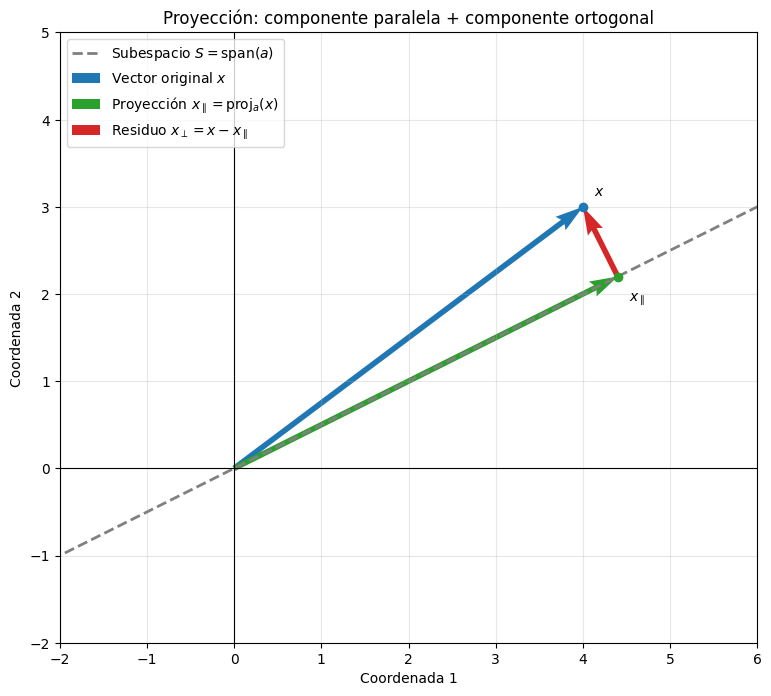

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Definimos los dos vectores en R^2
# ------------------------------------------------------------

# Vector que queremos descomponer
x = np.array([4.0, 3.0])

# Dirección que genera el subespacio S.
# En R^2, S es la recta que pasa por el origen y sigue a 'a'.
a = np.array([2.0, 1.0])

# ------------------------------------------------------------
# 2. Calculamos la proyección de x sobre la dirección a
# ------------------------------------------------------------

# Fórmula:
# proj_a(x) = [(x^T a) / (a^T a)] * a
#
# x @ a equivale a x^T a: producto punto.
# a @ a equivale a ||a||^2: norma al cuadrado.
x_paralelo = (x @ a) / (a @ a) * a

# El residuo es la parte que queda de x después de quitar
# la componente que sigue la dirección de a.
x_ortogonal = x - x_paralelo

# Comprobaciones geométricas
print("x =", x)
print("a =", a)
print("Componente paralela / proyección =", x_paralelo)
print("Componente ortogonal / residuo =", x_ortogonal)
print("Reconstrucción x_paralelo + x_ortogonal =", x_paralelo + x_ortogonal)
print("Producto punto a @ x_ortogonal =", a @ x_ortogonal)

# El último valor debe ser aproximadamente cero:
# a @ x_ortogonal ≈ 0
# Eso confirma que el residuo es perpendicular a la recta S.

# ------------------------------------------------------------
# 3. Función auxiliar para dibujar vectores como flechas
# ------------------------------------------------------------

def dibujar_vector(ax, inicio, vector, color, etiqueta):
    ax.quiver(
        inicio[0], inicio[1],
        vector[0], vector[1],
        angles="xy",
        scale_units="xy",
        scale=1,
        color=color,
        width=0.008,
        label=etiqueta
    )

# ------------------------------------------------------------
# 4. Gráfica geométrica de la descomposición
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 8))

# Recta S = span(a): todos los múltiplos de a
t = np.linspace(-2, 3, 100)
recta_S = np.outer(t, a)

ax.plot(
    recta_S[:, 0],
    recta_S[:, 1],
    color="gray",
    linestyle="--",
    linewidth=2,
    label=r"Subespacio $S = \mathrm{span}(a)$"
)

# Vector original: desde el origen hasta x
dibujar_vector(
    ax,
    inicio=np.array([0.0, 0.0]),
    vector=x,
    color="tab:blue",
    etiqueta=r"Vector original $x$"
)

# Proyección: desde el origen hasta x_paralelo
dibujar_vector(
    ax,
    inicio=np.array([0.0, 0.0]),
    vector=x_paralelo,
    color="tab:green",
    etiqueta=r"Proyección $x_{\parallel} = \mathrm{proj}_a(x)$"
)

# Residuo: va desde la punta de la proyección hasta la punta de x
dibujar_vector(
    ax,
    inicio=x_paralelo,
    vector=x_ortogonal,
    color="tab:red",
    etiqueta=r"Residuo $x_{\perp} = x - x_{\parallel}$"
)

# Segmento punteado que muestra la caída perpendicular a la recta S
ax.plot(
    [x_paralelo[0], x[0]],
    [x_paralelo[1], x[1]],
    linestyle=":",
    color="tab:red",
    linewidth=2
)

# Etiquetas de puntos importantes
ax.scatter(*x, color="tab:blue", zorder=3)
ax.scatter(*x_paralelo, color="tab:green", zorder=3)

ax.annotate(r"$x$", xy=x, xytext=(8, 8), textcoords="offset points")
ax.annotate(
    r"$x_{\parallel}$",
    xy=x_paralelo,
    xytext=(8, -18),
    textcoords="offset points"
)

# Formato visual
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_aspect("equal")
ax.set_xlim(-2, 6)
ax.set_ylim(-2, 5)
ax.set_xlabel("Coordenada 1")
ax.set_ylabel("Coordenada 2")
ax.set_title("Proyección: componente paralela + componente ortogonal")
ax.grid(alpha=0.3)
ax.legend(loc="upper left")

plt.show()

# <b> Mejor aproximación  </b>

- sea b, a vectores \in \R por ejemplo; si quiero aproximar el vector b usando solo multiplos de a, se busca el escalar c que haga la minima distancia:
$$ min_{c} || b - ca ||^2 $$

El residuo siempre es ortogonal a la direccion de la proyeccion, si fuera a la direccion contraria, seria oblicua. 

$$ a^T (b - proj_{a}b) = 0 $$

PROYECCIÓN ORTOGONAL
p_ort = [4.4 2.2]
r_ort = [-0.4  0.8]
a · r_ort = -8.88e-16  -> aproximadamente 0

PROYECCIÓN OBLICUA
p_obl = [2. 1.]
r_obl = [2. 2.]
a · r_obl = 6.00  -> no es 0


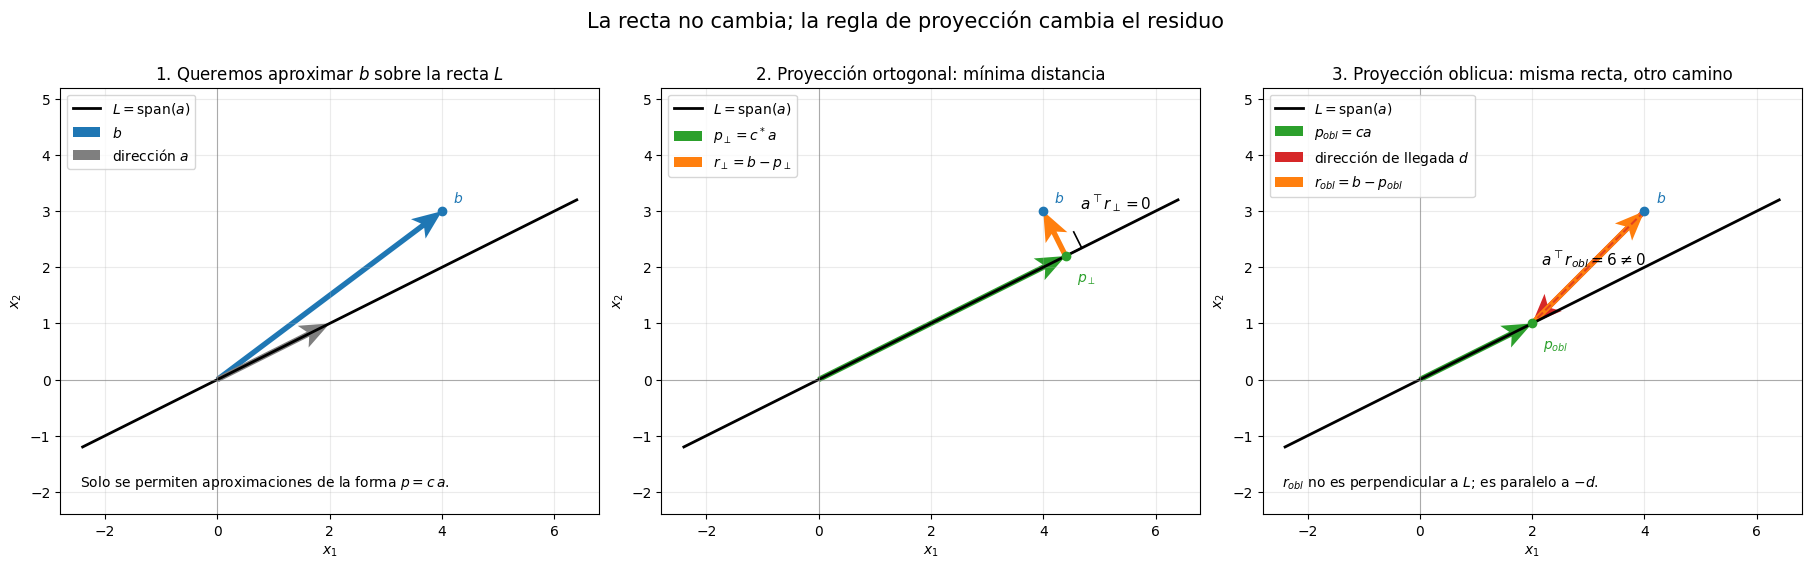

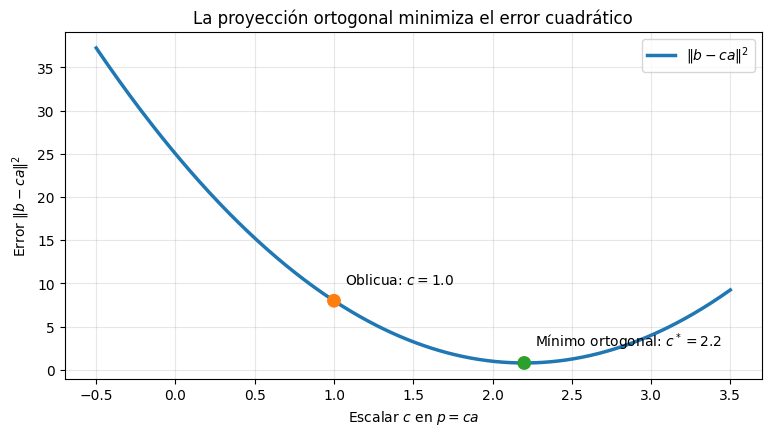

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# EL PROBLEMA:
# Queremos aproximar b usando solo puntos de la recta L = span(a)
# Es decir, buscamos puntos p = c*a
# ============================================================

b = np.array([4.0, 3.0])   # vector que queremos aproximar
a = np.array([2.0, 1.0])   # dirección de la recta objetivo L = span(a)

# ------------------------------------------------------------
# 1. Proyección ortogonal: la mejor aproximación euclidiana
# ------------------------------------------------------------

c_ort = (b @ a) / (a @ a)
p_ort = c_ort * a
r_ort = b - p_ort

# ------------------------------------------------------------
# 2. Proyección oblicua
# Queremos llegar a la misma recta, pero siguiendo d.
# d apunta desde b hacia la recta.
# El residuo r_obl = b - p_obl queda en dirección opuesta a d.
# ------------------------------------------------------------

d = np.array([-1.0, -1.0])

def cross2(u, v):
    """Producto cruzado en R²: cero significa que u y v son paralelos."""
    return u[0] * v[1] - u[1] * v[0]

# Buscamos c tal que b - c*a sea paralelo a d
c_obl = cross2(b, d) / cross2(a, d)
p_obl = c_obl * a
r_obl = b - p_obl

print("PROYECCIÓN ORTOGONAL")
print(f"p_ort = {p_ort}")
print(f"r_ort = {r_ort}")
print(f"a · r_ort = {a @ r_ort:.2e}  -> aproximadamente 0\n")

print("PROYECCIÓN OBLICUA")
print(f"p_obl = {p_obl}")
print(f"r_obl = {r_obl}")
print(f"a · r_obl = {a @ r_obl:.2f}  -> no es 0")

# ============================================================
# Funciones auxiliares para las gráficas
# ============================================================

def setup(ax, title):
    t = np.linspace(-1.2, 3.2, 200)

    # Recta objetivo: todos los puntos posibles p = c*a
    ax.plot(
        t * a[0], t * a[1],
        color="black", lw=2,
        label=r"$L=\mathrm{span}(a)$"
    )

    ax.axhline(0, color="gray", lw=0.8, alpha=0.6)
    ax.axvline(0, color="gray", lw=0.8, alpha=0.6)

    ax.set_xlim(-2.8, 6.8)
    ax.set_ylim(-2.4, 5.2)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.grid(alpha=0.25)


def arrow(ax, start, vector, color, label):
    ax.quiver(
        *start, *vector,
        angles="xy", scale_units="xy", scale=1,
        color=color,
        width=0.010,
        headwidth=4.5,
        headlength=5.5,
        label=label
    )

# ============================================================
# HISTORIA VISUAL: problema -> ortogonal -> oblicua
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)

# ------------------------------------------------------------
# ESCENA 1: Solo conocemos el problema
# ------------------------------------------------------------

ax = axes[0]
setup(ax, "1. Queremos aproximar $b$ sobre la recta $L$")

arrow(ax, (0, 0), b, "tab:blue", r"$b$")
arrow(ax, (0, 0), a, "tab:gray", r"dirección $a$")

ax.scatter(*b, color="tab:blue", zorder=3)
ax.annotate(r"$b$", b, xytext=(8, 6), textcoords="offset points", color="tab:blue")

ax.text(
    -2.45, -1.9,
    r"Solo se permiten aproximaciones de la forma $p=c\,a$.",
    fontsize=10
)

ax.legend(loc="upper left")

# ------------------------------------------------------------
# ESCENA 2: Proyección ortogonal = mejor aproximación
# ------------------------------------------------------------

ax = axes[1]
setup(ax, "2. Proyección ortogonal: mínima distancia")

arrow(ax, (0, 0), p_ort, "tab:green", r"$p_{\perp}=c^*a$")
arrow(ax, p_ort, r_ort, "tab:orange", r"$r_{\perp}=b-p_{\perp}$")

ax.scatter(*b, color="tab:blue", zorder=3)
ax.scatter(*p_ort, color="tab:green", zorder=3)

# Línea que une la proyección con b
ax.plot(
    [p_ort[0], b[0]],
    [p_ort[1], b[1]],
    "--",
    color="tab:orange",
    alpha=0.7
)

# Marcador visual de ángulo recto
u = a / np.linalg.norm(a)
v = r_ort / np.linalg.norm(r_ort)

q = p_ort + 0.32 * u
ax.plot(
    [p_ort[0], q[0], q[0] + 0.32 * v[0]],
    [p_ort[1], q[1], q[1] + 0.32 * v[1]],
    color="black",
    lw=1.2
)

ax.annotate(
    r"$a^\top r_{\perp}=0$",
    p_ort + np.array([0.25, 0.85]),
    fontsize=11
)

ax.annotate(r"$p_{\perp}$", p_ort, xytext=(8, -18),
            textcoords="offset points", color="tab:green")

ax.annotate(r"$b$", b, xytext=(8, 6),
            textcoords="offset points", color="tab:blue")

ax.legend(loc="upper left")

# ------------------------------------------------------------
# ESCENA 3: Proyección oblicua
# ------------------------------------------------------------

ax = axes[2]
setup(ax, "3. Proyección oblicua: misma recta, otro camino")

arrow(ax, (0, 0), p_obl, "tab:green", r"$p_{obl}=ca$")

# Dirección desde b hacia la recta
arrow(ax, b, p_obl - b, "tab:red", r"dirección de llegada $d$")

# El residuo apunta al revés: p_obl -> b
arrow(ax, p_obl, r_obl, "tab:orange", r"$r_{obl}=b-p_{obl}$")

ax.scatter(*b, color="tab:blue", zorder=3)
ax.scatter(*p_obl, color="tab:green", zorder=3)

ax.plot(
    [b[0], p_obl[0]],
    [b[1], p_obl[1]],
    "--",
    color="tab:red",
    alpha=0.7
)

ax.annotate(
    rf"$a^\top r_{{obl}}={a @ r_obl:.0f}\neq0$",
    p_obl + np.array([0.15, 1.05]),
    fontsize=11
)

ax.annotate(r"$p_{obl}$", p_obl, xytext=(8, -18),
            textcoords="offset points", color="tab:green")

ax.annotate(r"$b$", b, xytext=(8, 6),
            textcoords="offset points", color="tab:blue")

ax.text(
    -2.45, -1.9,
    r"$r_{obl}$ no es perpendicular a $L$; es paralelo a $-d$.",
    fontsize=10
)

ax.legend(loc="upper left")

fig.suptitle(
    "La recta no cambia; la regla de proyección cambia el residuo",
    fontsize=15,
    y=1.03
)

plt.show()

# ============================================================
# ¿Por qué la ortogonal es la "mejor aproximación"?
# ============================================================

c = np.linspace(-0.5, 3.5, 400)
error_cuadratico = np.array([np.linalg.norm(b - ci * a) ** 2 for ci in c])

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(c, error_cuadratico, color="tab:blue", lw=2.5, label=r"$\|b-ca\|^2$")

ax.scatter(
    [c_ort, c_obl],
    [np.linalg.norm(r_ort) ** 2, np.linalg.norm(r_obl) ** 2],
    color=["tab:green", "tab:orange"],
    s=80,
    zorder=3
)

ax.annotate(
    rf"Mínimo ortogonal: $c^*={c_ort:.1f}$",
    (c_ort, np.linalg.norm(r_ort) ** 2),
    xytext=(8, 12),
    textcoords="offset points"
)

ax.annotate(
    rf"Oblicua: $c={c_obl:.1f}$",
    (c_obl, np.linalg.norm(r_obl) ** 2),
    xytext=(8, 12),
    textcoords="offset points"
)

ax.set_title("La proyección ortogonal minimiza el error cuadrático")
ax.set_xlabel(r"Escalar $c$ en $p=ca$")
ax.set_ylabel(r"Error $\|b-ca\|^2$")
ax.grid(alpha=0.3)
ax.legend()

plt.show()

# <b> Proyeccion sobre un espacio </b>
Generalizando de una linea a un subespacio

ahora un subespacio $ S $  generado por varias direcciones es:
 $ S=\operatorname{Col}(A) = \operatorname{span}(a_1,a_2,\dots,a_k) $

donde:

$
A=
\begin{bmatrix}
| & | & & |\\
a_1 & a_2 & \cdots & a_k\\
| & | & & |
\end{bmatrix}.
$

La aproximación ya no es un solo escalar por un vector. Es una combinación lineal:
$ b \approx Ax $

donde:
$ x=
\begin{bmatrix}
x_1\\
x_2\\
\vdots\\
x_k
\end{bmatrix}.
$ 

La proyección ortogonal busca:
$ \hat{x}= \arg\min_x \|b-Ax\|^2. $ 

Y la proyección de \(b\) al subespacio es:
$ 
\hat b=A\hat{x}. $

El residuo es:
$
r=b-\hat b=b-A\hat{x}.
$

La proyeccion ahora queda como  $ proj_{col(A)}{b} =  AA^Tb$

 
<b> Si las columnas de A son linealmente independientes  </b> : El vector de coeficientes que indica cuánto usar de cada columna de A $ \hat x=(A^\top A)^{-1}A^\top b  $

$ \hat b $  sí es la proyección de $ b $ sobre el subespacio columna de $  A $:

$ \hat b=A\hat x= A(A^\top A)^{-1}A^\top b$ 

De hecho

$ P=A(A^\top A)^{-1}A^\top$ es la matriz de proyección, así que: $ \hat b=Pb. $


Matriz A:
 [[1. 0.]
 [0. 1.]
 [1. 1.]]

Vector b: [3. 2. 1.]

--- Coordenadas dentro del subespacio ---
x_hat = [1.66666667 0.66666667]

--- Proyección de b sobre Col(A) ---
b_hat = [1.66666667 0.66666667 2.33333333]
P @ b = [1.66666667 0.66666667 2.33333333]

--- Residuo ---
r = b - b_hat = [ 1.33333333  1.33333333 -1.33333333]

Verificación de ortogonalidad:
a1 · r = -2.220446049250313e-16
a2 · r = 0.0
A.T @ r = [-2.22044605e-16  0.00000000e+00]


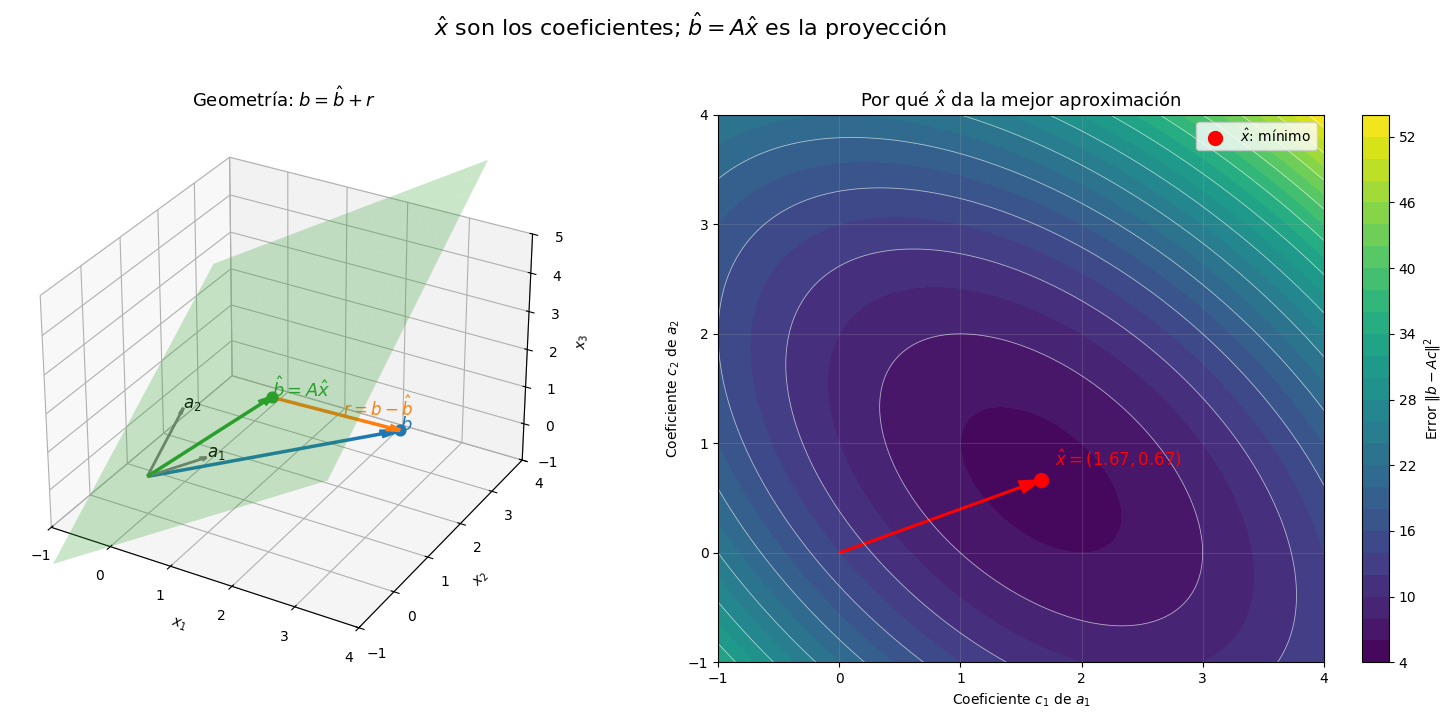

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PROYECCIÓN DE b SOBRE UN SUBESPACIO Col(A)
#
# Las columnas de A son dos vectores independientes:
# a1 y a2. Juntos generan un plano en R³.
# ============================================================

a1 = np.array([1.0, 0.0, 1.0])
a2 = np.array([0.0, 1.0, 1.0])

A = np.column_stack([a1, a2])

# Vector que queremos aproximar usando solo combinaciones
# de a1 y a2.
b = np.array([3.0, 2.0, 1.0])

# ============================================================
# 1. Resolver mínimos cuadrados
#
# x_hat son los coeficientes:
# b_hat = x1_hat*a1 + x2_hat*a2 = A @ x_hat
# ============================================================

x_hat = np.linalg.solve(A.T @ A, A.T @ b)

# b_hat SÍ es la proyección de b sobre Col(A)
b_hat = A @ x_hat

# El residuo queda perpendicular a todo el plano Col(A)
r = b - b_hat

# Matriz de proyección
P = A @ np.linalg.inv(A.T @ A) @ A.T

print("Matriz A:\n", A)
print("\nVector b:", b)

print("\n--- Coordenadas dentro del subespacio ---")
print("x_hat =", x_hat)

print("\n--- Proyección de b sobre Col(A) ---")
print("b_hat =", b_hat)
print("P @ b =", P @ b)

print("\n--- Residuo ---")
print("r = b - b_hat =", r)

print("\nVerificación de ortogonalidad:")
print("a1 · r =", a1 @ r)
print("a2 · r =", a2 @ r)
print("A.T @ r =", A.T @ r)

# ============================================================
# 2. Visualización:
# izquierda: geometría en R³
# derecha: función de error para todos los coeficientes c1, c2
# ============================================================

fig = plt.figure(figsize=(16, 7))

# ------------------------------------------------------------
# IZQUIERDA: plano Col(A), b, b_hat y residuo
# ------------------------------------------------------------

ax = fig.add_subplot(1, 2, 1, projection="3d")

# El plano generado por a1 y a2 es:
# p = c1*a1 + c2*a2
c1_grid = np.linspace(-1.0, 3.5, 20)
c2_grid = np.linspace(-1.0, 3.5, 20)

C1, C2 = np.meshgrid(c1_grid, c2_grid)

X = C1
Y = C2
Z = C1 + C2

ax.plot_surface(
    X, Y, Z,
    alpha=0.25,
    color="tab:green",
    edgecolor="none"
)

# Vectores base que generan el plano
ax.quiver(
    0, 0, 0, *a1,
    color="tab:gray",
    linewidth=2,
    arrow_length_ratio=0.10
)

ax.quiver(
    0, 0, 0, *a2,
    color="tab:gray",
    linewidth=2,
    arrow_length_ratio=0.10
)

# Vector original b
ax.quiver(
    0, 0, 0, *b,
    color="tab:blue",
    linewidth=2.5,
    arrow_length_ratio=0.08
)

# Proyección b_hat
ax.quiver(
    0, 0, 0, *b_hat,
    color="tab:green",
    linewidth=2.5,
    arrow_length_ratio=0.08
)

# Residuo: va desde b_hat hasta b
ax.quiver(
    *b_hat, *r,
    color="tab:orange",
    linewidth=2.5,
    arrow_length_ratio=0.10
)

# Línea punteada que muestra el salto desde b hasta el plano
ax.plot(
    [b_hat[0], b[0]],
    [b_hat[1], b[1]],
    [b_hat[2], b[2]],
    "--",
    color="tab:orange",
    alpha=0.8
)

# Puntos importantes
ax.scatter(*b, color="tab:blue", s=60)
ax.scatter(*b_hat, color="tab:green", s=60)

# Etiquetas
ax.text(*a1, r"$a_1$", color="black", fontsize=12)
ax.text(*a2, r"$a_2$", color="black", fontsize=12)

ax.text(*b, r"$b$", color="tab:blue", fontsize=13)
ax.text(*b_hat, r"$\hat{b}=A\hat{x}$", color="tab:green", fontsize=13)

residuo_medio = b_hat + 0.55 * r
ax.text(*residuo_medio, r"$r=b-\hat{b}$", color="tab:orange", fontsize=12)

ax.set_title(r"Geometría: $b=\hat{b}+r$", fontsize=13)
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_zlabel(r"$x_3$")

ax.set_xlim(-1, 4)
ax.set_ylim(-1, 4)
ax.set_zlim(-1, 5)

# ------------------------------------------------------------
# DERECHA: superficie de error ||b - A c||²
#
# Cada punto (c1, c2) representa una combinación:
# p = c1*a1 + c2*a2
# El mínimo ocurre en x_hat.
# ------------------------------------------------------------

ax2 = fig.add_subplot(1, 2, 2)

c1_values = np.linspace(-1, 4, 200)
c2_values = np.linspace(-1, 4, 200)

C1, C2 = np.meshgrid(c1_values, c2_values)

aproximaciones = (
    C1[..., np.newaxis] * a1
    + C2[..., np.newaxis] * a2
)

error = np.sum((b - aproximaciones) ** 2, axis=2)

contorno = ax2.contourf(C1, C2, error, levels=30, cmap="viridis")
fig.colorbar(contorno, ax=ax2, label=r"Error $\|b-Ac\|^2$")

ax2.contour(
    C1, C2, error,
    levels=12,
    colors="white",
    linewidths=0.6,
    alpha=0.6
)

# Punto mínimo: x_hat
ax2.scatter(
    *x_hat,
    color="red",
    s=100,
    zorder=3,
    label=r"$\hat{x}$: mínimo"
)

# Flecha desde el origen hasta x_hat:
# NO representa una proyección de b.
# Son los coeficientes que construyen b_hat.
ax2.arrow(
    0, 0,
    x_hat[0], x_hat[1],
    color="red",
    width=0.015,
    head_width=0.12,
    length_includes_head=True
)

ax2.annotate(
    rf"$\hat{{x}}=({x_hat[0]:.2f}, {x_hat[1]:.2f})$",
    xy=x_hat,
    xytext=(10, 10),
    textcoords="offset points",
    color="red",
    fontsize=12
)

ax2.set_title(
    r"Por qué $\hat{x}$ da la mejor aproximación",
    fontsize=13
)

ax2.set_xlabel(r"Coeficiente $c_1$ de $a_1$")
ax2.set_ylabel(r"Coeficiente $c_2$ de $a_2$")
ax2.legend()
ax2.grid(alpha=0.2)

fig.suptitle(
    r"$\hat{x}$ son los coeficientes; $\hat{b}=A\hat{x}$ es la proyección",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()